# Grounding Dataset Pipeline - `groundrails.dataset`

**Author**: Konrad Jelen (kj) <br>
**Date**: 2026-08-14 <br>
**Module**: `groundrails.dataset` (extra `groundrails[dataset]`) <br>

Drives the six-stage corpus preprocessing pipeline end to end, through its public Python API - the same
calls the `groundrails dataset ...` CLI makes. The pipeline turns a declared corpus into a training lane
and rules on whether that lane is admissible, all on CPU, before a GPU is ever touched.

The stage that earns the pipeline is **shape**. A corpus that passes a licence check and a contamination
gate is legal and unseen; neither says what its evidence costs to train on. Evidence is presented to the
trainer as sliding windows and the loss is per WINDOW PAIR, so a row carrying a whole article is not one
training example - it is dozens:

$$\text{pairs}(r) = \left\lceil \frac{\max(0,\; |c_r| - W)}{S} \right\rceil + 1
\qquad W = 1500,\; S = 750$$

A corpus of whole articles therefore takes a share of the gradient far larger than its share of the rows.
The shape stage measures that share before the run, and blocks on it.

## Approach
1. **Fetch** - acquire each corpus from its manifest entry; cache-aware and idempotent
2. **Contaminate** - 8-gram Jaccard overlap against the walled arena, bidirectional, with a spike control
3. **Format** - normalise to the pair schema `claim, chunk, label, doc_id, source, tag`
4. **Shape** - windows per row, document reuse, projected pair share → PASS / PASS-WITH-DROP / BLOCK
5. **Assemble** - build the mix from the admitted lanes, with declared assertions and documented drops
6. **Census** - per-group rows, pairs, pair share and mean target; one go/no-go

## Outputs
- `data/interim/lanes/<corpus>_lane.parquet` + `_lane_manifest.json` - one formatted lane per corpus
- `data/interim/lanes/mix.parquet` - the assembled mix, pair schema plus a `group` column
- In-notebook: the manifest, gate verdicts, the shape-gate table, the census, and two composition figures

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
import io  # in-memory read of the arena parquets inside their archive
import random  # seeded sampling
import zipfile  # the walled arena ships as an archive of parquets
from pathlib import Path  # every path in this notebook

# Data processing
import numpy as np  # seeds and the share arithmetic behind the figures
import polars as pl  # every dataframe operation (no pandas anywhere in this module)

# Plotting
import matplotlib.pyplot as plt  # inline composition figures

# groundrails dataset pipeline - the public API, one import per stage
from groundrails.dataset import (
    MixProjection,  # the mix a lane's pair share is projected into
    MixSpec,        # stage 5 - the mix declared before it is built
    LaneSpec,       # stage 5 - one lane in that mix, with the counts it must reproduce
    assemble,       # stage 5
    census,         # stage 6
    contamination_check,  # stage 2
    evidence_texts,       # the deduplicated gate units a corpus contributes
    fetch,                # stage 1
    format_corpus,        # stage 3
    load_manifest,        # the corpus manifest (corpora.yaml), validated on load
    shape,                # stage 4
    write_lane,           # stage 3 output
)

# Rich console output
from rich import print as rprint  # formatted console printing
from rich.console import Console  # a widened console so the wide stage tables do not truncate
from rich.table import Table  # the manifest, gate, shape and census tables
from rich.progress import (  # progress bars over the per-corpus loops
    BarColumn,
    MofNCompleteColumn,
    Progress,
    SpinnerColumn,
    TextColumn,
    TimeElapsedColumn,
)

In [2]:
SEED = 42  # arena sampling and every shuffle below

random.seed(SEED)
np.random.seed(SEED)

In [3]:
# Paths - resolved from the repo root so the notebook runs from anywhere
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIR = PROJECT_ROOT / "data" / "external" / "datasets"   # fetched archives and trees
LANE_DIR = PROJECT_ROOT / "data" / "interim" / "lanes"       # formatted lanes land here
ARENA_ARCHIVE = DATA_DIR / "dataset-ragbench.zip"            # the walled corpora, as fetched

# Corpora - the six with a pair-format block in the manifest
CORPORA = ["fava", "pubhealth", "minicheck", "factscore", "findver", "attributionbench"]

# Fetch - the archives are already on disk; the stage detects that and skips the download
FORCE_REFETCH = False           # True re-downloads even when a checkpoint exists

# Contaminate - arena construction and how much of each corpus to gate in-notebook
ARENA_PER_SUBSET = 250          # rows sampled per walled subset
ARENA_MAX_CHUNKS = 8            # document chunks kept per sampled row
GATE_SAMPLE = 1500              # candidate evidence units gated here (the CLI gates all of them)
GATE_N = 8                      # n-gram size
GATE_JACCARD = 0.3              # a unit hits at this Jaccard against any single walled unit

# Shape - the mix these lanes are candidates for. Totals are the banked incumbent mix at
# full presentation (1500/750 windows), which already contains the five admitted lanes.
MIX_NAME = "incumbent mix"
MIX_PAIRS = 1_299_149           # training pairs in the incumbent mix
MIX_ROWS = 796_734              # rows in the incumbent mix
IN_MIX = {"fava", "pubhealth", "minicheck", "findver", "attributionbench"}  # already members

# Palette - one system for rich output and every figure
COLOR_ROWS = "#3498DB"          # primary: rows
COLOR_PAIRS = "#E74C3C"         # secondary: training pairs
COLOR_OK = "#2ECC71"            # tertiary: admitted

CONSOLE = Console(width=150)   # stage tables carry 12+ columns; the default width truncates them
LANE_DIR.mkdir(parents=True, exist_ok=True)

rprint(
    f"[bold medium_purple]Configuration[/bold medium_purple]\n"
    f"[dim]{'─' * 62}[/dim]\n"
    f"[bold slate_blue1]Paths[/bold slate_blue1]\n"
    f"  Project root: [dim]{PROJECT_ROOT}[/dim]\n"
    f"  Fetched data: [dim]{DATA_DIR.relative_to(PROJECT_ROOT)}[/dim]\n"
    f"  Lane output:  [dim]{LANE_DIR.relative_to(PROJECT_ROOT)}[/dim]\n"
    f"  Walled arena: [cadet_blue]{ARENA_ARCHIVE.name}[/cadet_blue]\n\n"
    f"[bold slate_blue1]Corpora[/bold slate_blue1]\n"
    f"  Selected: [dark_sea_green]{len(CORPORA)}[/dark_sea_green] "
    f"[grey70]{', '.join(CORPORA)}[/grey70]\n"
    f"  Re-fetch: [grey70]{FORCE_REFETCH}[/grey70] [dim](archives already on disk are reused)[/dim]\n\n"
    f"[bold slate_blue1]Contamination gate[/bold slate_blue1]\n"
    f"  n-gram: [dark_sea_green]{GATE_N}[/dark_sea_green]   "
    f"Jaccard: [dark_sea_green]{GATE_JACCARD}[/dark_sea_green]   "
    f"candidate sample: [light_sea_green]{GATE_SAMPLE:,} units[/light_sea_green]\n"
    f"  Arena: [light_sea_green]{ARENA_PER_SUBSET} rows x {ARENA_MAX_CHUNKS} chunks[/light_sea_green] "
    f"[dim]per walled subset[/dim]\n\n"
    f"[bold slate_blue1]Projection[/bold slate_blue1]\n"
    f"  Mix: [cadet_blue]{MIX_NAME}[/cadet_blue]   "
    f"rows [light_sea_green]{MIX_ROWS:,}[/light_sea_green]   "
    f"pairs [light_sea_green]{MIX_PAIRS:,}[/light_sea_green]\n"
    f"  Already members: [grey70]{', '.join(sorted(IN_MIX))}[/grey70]\n\n"
    f"[bold slate_blue1]Reproducibility[/bold slate_blue1]\n"
    f"  Seed: [dark_sea_green]{SEED}[/dark_sea_green]   "
    f"Device: [dark_sea_green]CPU only[/dark_sea_green] [dim](no GPU in this pipeline)[/dim]"
)

Configuration
──────────────────────────────────────────────────────────────
Paths
  Project root: /home/lab/workspace/private/ai-assistants/groundrails
  Fetched data: data/external/datasets
  Lane output:  data/interim/lanes
  Walled arena: dataset-ragbench.zip

Corpora
  Selected: 6 fava, pubhealth, minicheck, factscore, findver, attributionbench
  Re-fetch: False (archives already on disk are reused)

Contamination gate
  n-gram: 8   Jaccard: 0.3   candidate sample: 1,500 units
  Arena: 250 rows x 8 chunks per walled subset

Projection
  Mix: incumbent mix   rows 796,734   pairs 1,299,149
  Already members: attributionbench, fava, findver, minicheck, pubhealth

Reproducibility
  Seed: 42   Device: CPU only (no GPU in this pipeline)

## Manifest - the corpora, declared as data

Every corpus the pipeline knows is one entry in `corpora.yaml` inside the package: its source, the
licence tag read at that source, how its columns map onto the pair schema, the counts it must reproduce,
and the presentation the shape stage rules on. The manifest is validated on load, so a malformed or
incomplete entry fails here rather than half way through a fetch.

In [4]:
manifest = load_manifest()
entries = [manifest.get(name) for name in CORPORA]

manifest_df = pl.DataFrame(
    [
        {
            "corpus": e.name,
            "licence": e.licence.tag,
            "commercial": e.licence.commercial_use,
            "source": e.source.kind,
            "storage": e.storage,
            "format": e.format.adapter or "declarative",
            "expected_rows": e.expected.rows,
            "expected_docs": e.expected.documents,
        }
        for e in entries
    ]
)

table = Table(title=f"corpora.yaml - {len(manifest.names())} corpora declared, {len(CORPORA)} selected")
for col, style in [
    ("corpus", "grey70"),
    ("licence", "steel_blue"),
    ("source", "light_coral"),
    ("storage", "light_coral"),
    ("format", "cadet_blue"),
    ("rows", "dark_sea_green"),
    ("documents", "dark_sea_green"),
]:
    table.add_column(col, style=style, justify="right" if col in ("rows", "documents") else "left")
for r in manifest_df.iter_rows(named=True):
    table.add_row(
        r["corpus"],
        r["licence"],
        r["source"],
        r["storage"],
        r["format"],
        f"{r['expected_rows']:,}",
        f"{r['expected_docs']:,}",
    )
CONSOLE.print(table)

                     corpora.yaml - 16 corpora declared, 6 selected                      
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ corpus           ┃ licence    ┃ source   ┃ storage ┃ format      ┃   rows ┃ documents ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ fava             │ CC-BY-4.0  │ hf_files │ archive │ fava        │ 30,073 │    30,073 │
│ pubhealth        │ MIT        │ adapter  │ archive │ declarative │ 12,251 │    12,251 │
│ minicheck        │ MIT        │ hf_files │ archive │ declarative │ 14,356 │     6,155 │
│ factscore        │ MIT        │ adapter  │ tree    │ factscore   │ 13,653 │       181 │
│ findver          │ MIT        │ http_zip │ tree    │ findver     │  2,400 │       539 │
│ attributionbench │ Apache-2.0 │ hf_files │ archive │ declarative │ 16,444 │    12,138 │
└──────────────────┴────────────┴──────────┴─────────┴─────────────┴────────┴───────────┘

In [5]:
rprint(
    "[bold medium_purple]Task shapes as declared[/bold medium_purple]\n"
    + "\n".join(f"  [grey70]{e.name:<17}[/grey70] {e.task_shape}" for e in entries)
)

Task shapes as declared
  fava              prompt `Text:` passage -> claim; `Reference ` blocks -> evidence; any error span in the tagged 
completion -> 0, clean -> 1
  pubhealth         claim -> claim; source article `main_text` -> evidence; true -> 1, false/unproven/mixture -> 0
  minicheck         claim -> claim; doc -> evidence; shipped label (1 supported / 0 not)
  factscore         atomic fact -> claim; the topic's pinned Wikipedia article -> evidence; S -> 1, NS -> 0 (IR 
excluded - off-topic, support undefined)
  findver           statement -> claim; the annotated `relevant_context` passages -> evidence; entailed -> 1, 
refuted -> 0
  attributionbench  claim -> claim; references -> evidence; attributable -> 1, not attributable -> 0

## Stage 1 - Fetch

Acquires each corpus into `data/external/datasets/` from its manifest entry: an `archive` corpus is
staged as parquet then zipped, a `tree` corpus lands as an extracted directory. The stage is idempotent -
a corpus whose checkpoint is already on disk is returned from cache with no network traffic, which is
what happens on every run below.

In [6]:
present = {
    e.name: (DATA_DIR / f"dataset-{e.name}.zip").exists() or (DATA_DIR / e.name / "_counts.json").exists()
    for e in entries
}
rprint(
    f"[bold medium_purple]Fetch pre-flight[/bold medium_purple]\n"
    f"  Checkpoints on disk: [dark_sea_green]{sum(present.values())}[/dark_sea_green] of "
    f"[dark_sea_green]{len(present)}[/dark_sea_green]\n"
    f"  Missing: [grey70]{', '.join(n for n, ok in present.items() if not ok) or 'none'}[/grey70]\n"
    f"[dim]Cached corpora are reused untouched - no download, no re-parse.[/dim]"
)

Fetch pre-flight
  Checkpoints on disk: 6 of 6
  Missing: none
Cached corpora are reused untouched - no download, no re-parse.

In [7]:
fetch_results = {}
with Progress(
    SpinnerColumn(),
    TextColumn("[steel_blue]{task.description}"),
    BarColumn(bar_width=40),
    MofNCompleteColumn(),
    TimeElapsedColumn(),
    refresh_per_second=10,
) as progress:
    task = progress.add_task("Fetching corpora", total=len(entries))
    for e in entries:
        fetch_results[e.name] = fetch(e, DATA_DIR, force=FORCE_REFETCH)
        progress.advance(task)
    progress.update(task, completed=len(entries))
    progress.refresh()

Output()

In [8]:
table = Table(title="Stage 1 - fetch")
table.add_column("corpus", style="grey70")
table.add_column("status", style="steel_blue")
table.add_column("storage", style="light_coral")
table.add_column("splits", style="dark_sea_green", justify="right")
table.add_column("artefact", style="dim")
for name, res in fetch_results.items():
    splits = {k: v for k, v in res.counts.items() if isinstance(v, int) and not k.startswith("_")}
    status = "[dark_sea_green]cached[/dark_sea_green]" if res.status == "cached" else res.status
    table.add_row(
        name,
        status,
        res.storage,
        f"{sum(splits.values()):,}",
        str(res.path.relative_to(PROJECT_ROOT)) if res.path else "-",
    )
CONSOLE.print(table)

                                           Stage 1 - fetch                                            
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ corpus           ┃ status ┃ storage ┃ splits ┃ artefact                                            ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ fava             │ cached │ archive │ 30,533 │ data/external/datasets/dataset-fava.zip             │
│ pubhealth        │ cached │ archive │ 12,288 │ data/external/datasets/dataset-pubhealth.zip        │
│ minicheck        │ cached │ archive │ 14,395 │ data/external/datasets/dataset-minicheck.zip        │
│ factscore        │ cached │ tree    │    732 │ data/external/datasets/factscore                    │
│ findver          │ cached │ tree    │  2,400 │ data/external/datasets/findver                      │
│ attributionbench │ cached │ archive │ 16,524 │ data/external/datasets/dataset-attributionbench.zip │
└──────────────────┴────────┴─────────┴────────┴─────────────────────────────────────────────────────┘

## Stage 2 - Contaminate

Measures 8-gram overlap between each corpus's deduplicated evidence and the walled arena, in BOTH
directions, and kills at 2% of the candidate. The spike control runs first: known arena units are
injected into the candidate side and every one must come back, because a clean verdict from a gate that
cannot fire is worse than no gate at all.

In [9]:
# The walled arena: document chunks from the ten RAGBench subsets held out of training.
# Only n-grams of these texts are ever read - never item content, never labels.
z = zipfile.ZipFile(ARENA_ARCHIVE)
walled = {}
for member in sorted(n for n in z.namelist() if n.endswith("__test.parquet")):
    subset = member.split("__")[2]
    df = pl.read_parquet(io.BytesIO(z.read(member))).filter(
        pl.col("adherence_score").is_not_null()
        & (pl.col("response").str.len_chars() > 20)
        & (pl.col("documents").list.len() > 0)
    )
    if len(df) < 40 or df["adherence_score"].n_unique() < 2:
        continue
    df = df.sample(min(ARENA_PER_SUBSET, len(df)), seed=SEED)
    walled[subset] = [c for docs in df["documents"].to_list() for c in docs[:ARENA_MAX_CHUNKS]]

rprint(
    f"[bold medium_purple]Walled arena[/bold medium_purple]\n"
    f"  Buckets: [dark_sea_green]{len(walled)}[/dark_sea_green] "
    f"[grey70]{', '.join(walled)}[/grey70]\n"
    f"  Units:   [light_sea_green]{sum(len(v) for v in walled.values()):,} document chunks[/light_sea_green]"
)

Walled arena
  Buckets: 10 covidqa, delucionqa, emanual, expertqa, finqa, hagrid, hotpotqa, pubmedqa, tatqa, techqa
  Units:   8,612 document chunks

In [10]:
gate_results = {}
with Progress(
    SpinnerColumn(),
    TextColumn("[steel_blue]{task.description}"),
    BarColumn(bar_width=40),
    MofNCompleteColumn(),
    TimeElapsedColumn(),
    refresh_per_second=10,
) as progress:
    task = progress.add_task("Gating corpora", total=len(entries))
    for e in entries:
        units = evidence_texts(e, DATA_DIR)
        gate_results[e.name] = contamination_check(
            units[:GATE_SAMPLE], walled, n=GATE_N, jaccard=GATE_JACCARD, label=e.name
        )
        gate_results[e.name]["units_available"] = len(units)
        progress.advance(task)
    progress.update(task, completed=len(entries))
    progress.refresh()

Output()

In [11]:
table = Table(title=f"Stage 2 - contamination gate ({GATE_N}-gram, Jaccard >= {GATE_JACCARD}, bidirectional)")
table.add_column("corpus", style="grey70")
table.add_column("evidence units", style="dark_sea_green", justify="right")
table.add_column("gated", style="dark_sea_green", justify="right")
table.add_column("spike", style="steel_blue", justify="right")
table.add_column("baseline hits", style="light_coral", justify="right")
table.add_column("max fraction", style="light_sea_green", justify="right")
table.add_column("verdict", justify="left")
for name, res in gate_results.items():
    spike, gate = res["spike_control"], res["gate"]
    colour = "dark_sea_green" if res["status"] == "GREEN" else "indian_red"
    table.add_row(
        name,
        f"{res['units_available']:,}",
        f"{gate['candidate']['n_units']:,}",
        f"{spike['detected_total']}/{spike['injected']}",
        str(spike["baseline_hits"]),
        f"{gate['max_fraction']:.6f}",
        f"[{colour}]{res['status']}[/{colour}] [dim]({gate['verdict']})[/dim]",
    )
CONSOLE.print(table)

               Stage 2 - contamination gate (8-gram, Jaccard >= 0.3, bidirectional)                
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ corpus           ┃ evidence units ┃ gated ┃ spike ┃ baseline hits ┃ max fraction ┃ verdict      ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ fava             │         30,072 │ 1,500 │ 10/10 │             0 │     0.000000 │ GREEN (PASS) │
│ pubhealth        │         11,943 │ 1,500 │ 10/10 │             0 │     0.000000 │ GREEN (PASS) │
│ minicheck        │          6,155 │ 1,500 │ 10/10 │             0 │     0.000000 │ GREEN (PASS) │
│ factscore        │            181 │   181 │ 10/10 │             0 │     0.000000 │ GREEN (PASS) │
│ findver          │          2,370 │ 1,500 │ 11/10 │             1 │     0.000667 │ GREEN (PASS) │
│ attributionbench │         12,138 │ 1,500 │ 10/10 │             0 │     0.000000 │ GREEN (PASS) │
└──────────────────┴────────────────┴───────┴───────┴───────────────┴──────────────┴──────────────┘

## Stage 3 - Format

Normalises each fetched corpus into the pair schema `claim, chunk, label, doc_id, source, tag`, plus the
provenance columns that corpus is worth keeping. Three of the six are pure column mapping declared in
the manifest; FAVA, FActScore and FinDVer need an adapter because their rows have to be parsed out of
tagged text or walked across a directory tree. The manifest's expected counts are held on the way out.

In [12]:
lanes = {}
lane_paths = {}
with Progress(
    SpinnerColumn(),
    TextColumn("[steel_blue]{task.description}"),
    BarColumn(bar_width=40),
    MofNCompleteColumn(),
    TimeElapsedColumn(),
    refresh_per_second=10,
) as progress:
    task = progress.add_task("Formatting lanes", total=len(entries))
    for e in entries:
        result = format_corpus(e, DATA_DIR)          # strict: the manifest counts must reproduce
        lane_paths[e.name] = write_lane(result, e, LANE_DIR)
        lanes[e.name] = result
        progress.advance(task)
    progress.update(task, completed=len(entries))
    progress.refresh()

Output()

In [13]:
table = Table(title="Stage 3 - formatted lanes")
table.add_column("corpus", style="grey70")
table.add_column("rows", style="dark_sea_green", justify="right")
table.add_column("positives", style="dark_sea_green", justify="right")
table.add_column("pos rate", style="light_sea_green", justify="right")
table.add_column("documents", style="steel_blue", justify="right")
table.add_column("provenance columns", style="cadet_blue")
table.add_column("integrity", justify="left")
for name, result in lanes.items():
    df = result.frame
    ok = result.integrity["pass"]
    prov = [c for c in df.columns if c not in ("pair_id", "claim", "chunk", "label", "doc_id", "source", "tag")]
    table.add_row(
        name,
        f"{df.height:,}",
        f"{int(df['label'].sum()):,}",
        f"{df['label'].mean():.3f}",
        f"{result.integrity['distinct_documents']:,}",
        f"{len(prov)} [dim]{', '.join(prov[:3])}{'...' if len(prov) > 3 else ''}[/dim]",
        "[dark_sea_green]pass[/dark_sea_green]" if ok else "[indian_red]FAIL[/indian_red]",
    )
CONSOLE.print(table)

                                                  Stage 3 - formatted lanes                                                   
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ corpus           ┃   rows ┃ positives ┃ pos rate ┃ documents ┃ provenance columns                              ┃ integrity ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ fava             │ 30,073 │       637 │    0.021 │    30,073 │ 5 n_spans, error_types, spans_json...           │ pass      │
│ pubhealth        │ 12,251 │     6,306 │    0.515 │    12,251 │ 5 explanation, fact_checkers, subjects...       │ pass      │
│ minicheck        │ 14,356 │     6,638 │    0.462 │     6,155 │ 0                                               │ pass      │
│ factscore        │ 13,653 │     9,332 │    0.684 │       181 │ 4 sentence, sentence_is_relevant, wiki_oldid... │ pass      │
│ findver          │  2,400 │     1,201 │    0.500 │       539 │ 5 example_id, subset, explanation...            │ pass      │
│ attributionbench │ 16,444 │    10,656 │    0.648 │    12,138 │ 3 src_dataset, question, ab_id                  │ pass      │
└──────────────────┴────────┴───────────┴──────────┴───────────┴─────────────────────────────────────────────────┴───────────┘

## Stage 4 - Shape

The gate this module exists for. Each lane is measured at the presentation its manifest declares -
1500-character windows at stride 750, 96 pairs per batch - and ruled on: windows per row, rows over the
batch cap, distinct documents and rows-per-document reuse, and the share of the mix's training pairs the
lane would take. Verdicts are PASS, PASS-WITH-DROP (over-cap rows, counted and named) and BLOCK
(structural - document reuse or pair-share capture).

In [14]:
# The rest of the mix: subtract a lane that is already a member, keep the whole
# for a candidate the mix does not yet contain.
def projection_for(name: str, own_pairs: int, own_rows: int) -> MixProjection:
    if name in IN_MIX:
        return MixProjection(MIX_NAME, MIX_PAIRS - own_pairs, MIX_ROWS - own_rows)
    return MixProjection(MIX_NAME, MIX_PAIRS, MIX_ROWS)


reports = []
for e in entries:
    df = lanes[e.name].frame
    unprojected = shape(df, e.presentation, name=e.name)   # first pass: this lane's own pair count
    reports.append(
        shape(
            df,
            e.presentation,
            name=e.name,
            projection=projection_for(e.name, unprojected.pairs, df.height),
        )
    )

In [15]:
VERDICT_COLOUR = {"PASS": "dark_sea_green", "PASS-WITH-DROP": "dark_goldenrod", "BLOCK": "indian_red"}

table = Table(title="Stage 4 - shape gate (windows 1500/750, batch cap 96 pairs)")
for col in ["corpus", "rows", "pairs", "win/row", "p90", "max", "over cap", "docs", "rows/doc", "pos", "pair share", "amp"]:
    table.add_column(
        col,
        style="grey70" if col == "corpus" else "dark_sea_green",
        justify="left" if col == "corpus" else "right",
    )
table.add_column("verdict", justify="left")
for r in reports:
    table.add_row(
        r.name,
        f"{r.rows:,}",
        f"{r.pairs:,}",
        f"{r.windows['mean']:.2f}",
        f"{r.windows['p90']:.0f}",
        f"{r.windows['max']:,}",
        f"{r.over_cap_rows:,}",
        f"{r.documents:,}",
        f"{r.rows_per_document:.2f}",
        f"{r.positive_fraction:.3f}",
        f"{r.projected_pair_share:.2%}",
        f"{r.pair_share_amplification:.1f}x",
        f"[{VERDICT_COLOUR[r.verdict]}]{r.verdict}[/{VERDICT_COLOUR[r.verdict]}]",
    )
CONSOLE.print(table)

                                       Stage 4 - shape gate (windows 1500/750, batch cap 96 pairs)                                        
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ corpus           ┃   rows ┃   pairs ┃ win/row ┃ p90 ┃ max ┃ over cap ┃   docs ┃ rows/doc ┃   pos ┃ pair share ┃   amp ┃ verdict        ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ fava             │ 30,073 │ 102,700 │    3.42 │   4 │   6 │        0 │ 30,073 │     1.00 │ 0.021 │      7.91% │  2.1x │ PASS           │
│ pubhealth        │ 12,251 │  65,807 │    5.37 │  10 │  55 │        0 │ 12,251 │     1.00 │ 0.515 │      5.07% │  3.3x │ PASS           │
│ minicheck        │ 14,356 │  16,001 │    1.11 │   2 │   3 │        0 │  6,155 │     2.33 │ 0.462 │      1.23% │  0.7x │ PASS           │
│ factscore        │ 13,653 │ 547,538 │   40.10 │  95 │ 242 │    1,341 │    181 │    75.43 │ 0.683 │     29.65% │ 17.6x │ BLOCK          │
│ findver          │  2,400 │   9,569 │    3.99 │   8 │  44 │        0 │    539 │     4.45 │ 0.500 │      0.74% │  2.5x │ PASS           │
│ attributionbench │ 16,444 │  36,167 │    2.20 │   3 │ 533 │       18 │ 12,138 │     1.35 │ 0.648 │      2.78% │  1.4x │ PASS-WITH-DROP │
└──────────────────┴────────┴─────────┴─────────┴─────┴─────┴──────────┴────────┴──────────┴───────┴────────────┴───────┴────────────────┘

In [16]:
rprint(
    "[bold medium_purple]Why each verdict[/bold medium_purple]\n"
    + "\n".join(
        f"  [{VERDICT_COLOUR[r.verdict]}]{r.verdict:<15}[/{VERDICT_COLOUR[r.verdict]}] "
        f"[grey70]{r.name}[/grey70]\n"
        + ("".join(f"      [dim]- {reason}[/dim]\n" for reason in r.reasons) or "      [dim]- no bar approached[/dim]\n")
        for r in reports
    ).rstrip()
    + "\n[bold]Evidence length is the mechanism[/bold]: "
    + ", ".join(f"[grey70]{r.name}[/grey70] [light_sea_green]{r.chunk_chars['mean']:,.0f}[/light_sea_green]" for r in reports)
    + " [dim]mean characters per row[/dim]"
)

Why each verdict
  PASS            fava
      - no bar approached

  PASS            pubhealth
      - no bar approached

  PASS            minicheck
      - no bar approached

  BLOCK           factscore
      - document reuse: 75.4 rows per document over the 20 bar (13653 rows over 181 documents)
      - pair-share capture: 29.65% of incumbent mix's pairs from 1.68% of its rows (17.6x, over the 3x bar at 15%+ 
share)
      - over-cap tail: 9.82% of rows exceed the 96-pair batch cap, over the 2% droppable bar

  PASS            findver
      - no bar approached

  PASS-WITH-DROP  attributionbench
      - drop 18 rows over the 96-pair batch cap
Evidence length is the mechanism: fava 2,972, pubhealth 4,375, minicheck 999, factscore 30,426, findver 3,324, 
attributionbench 1,428 mean characters per row

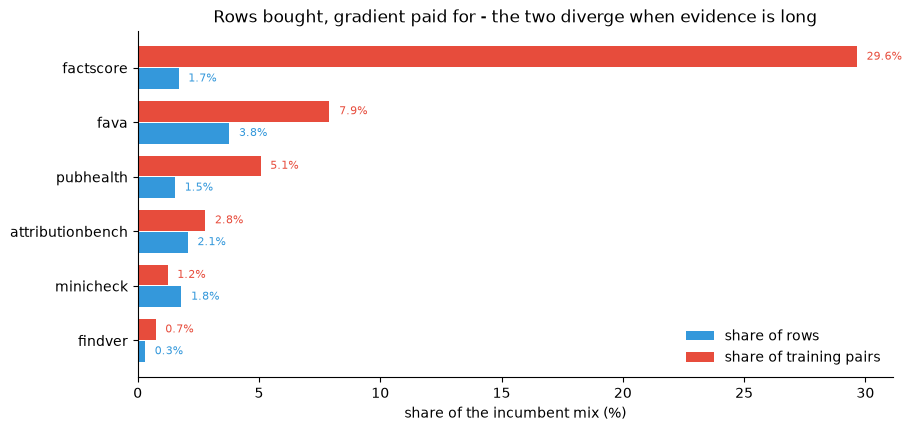

In [17]:
# The finding, drawn: share of the mix's ROWS against share of its training PAIRS.
order = sorted(reports, key=lambda r: r.projected_pair_share)
names = [r.name for r in order]
row_share = np.array([r.projected_row_share for r in order]) * 100
pair_share = np.array([r.projected_pair_share for r in order]) * 100
y = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
ax.barh(y - 0.2, row_share, height=0.38, color=COLOR_ROWS, label="share of rows")
ax.barh(y + 0.2, pair_share, height=0.38, color=COLOR_PAIRS, label="share of training pairs")
for i, (rs, ps) in enumerate(zip(row_share, pair_share)):
    ax.text(rs + 0.4, i - 0.2, f"{rs:.1f}%", va="center", fontsize=8, color=COLOR_ROWS)
    ax.text(ps + 0.4, i + 0.2, f"{ps:.1f}%", va="center", fontsize=8, color=COLOR_PAIRS)
ax.set_yticks(y, names)
ax.set_xlabel("share of the incumbent mix (%)")
ax.set_title("Rows bought, gradient paid for - the two diverge when evidence is long")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Reading the shape gate

FActScore is the case the stage was built for. Its rows are ordinary - 13,653 of them, 1.7% of the mix -
but its evidence is a whole Wikipedia article per row, 30,426 characters on average, which windows into
40.10 training pairs per row against a cap of 96 pairs per batch.

- **Mechanism** - 181 distinct articles back all 13,653 rows (75.4 rows per document), and long evidence
  multiplies into windows, so the lane would take 29.65% of the mix's training pairs from 1.7% of its
  rows - 17.6x its fair share
- **Meaning** - the domain-adversarial loss is per pair, so a third of the gradient would come from 181
  documents; a document-disjoint split has almost nothing to split on
- **Impact** - BLOCK. Not droppable either: 1,341 rows exceed the batch cap, 9.8% of the lane, far past
  the 2% that separates a tail from a misfit

AttributionBench is the opposite shape: 18 rows out of 16,444 concatenate very long reference sets, the
largest windowing into 533 pairs. That is 0.1% of the lane, so it is PASS-WITH-DROP - the 18 rows are
dropped by the trainer's own cap rule and counted, never silently filtered. The other four pass as
presented.

## Stage 5 - Assemble

Builds the mix from the lanes the shape gate admitted - the BLOCK verdict decides membership, not a
hand-kept list. Every count is declared before the build: each lane's rows and positives, the mix total,
the exact group map. Over-cap rows are dropped by the trainer's own rule and recorded with their window
counts, so the drop is documented rather than discovered later.

In [18]:
admitted = [r for r in reports if r.verdict != "BLOCK"]
blocked = [r for r in reports if r.verdict == "BLOCK"]

lane_specs = tuple(
    LaneSpec(
        path=lane_paths[r.name],
        group=r.name,
        expected_rows=r.rows,
        expected_positives=int(lanes[r.name].frame["label"].sum()),
    )
    for r in admitted
)
mix_spec = MixSpec(
    name="R19 supply mix",
    lanes=lane_specs,
    expected_groups=tuple(r.name for r in admitted),
    presentation=manifest.get(admitted[0].name).presentation,
)
mix = assemble(mix_spec)
mix.frame.write_parquet(LANE_DIR / "mix.parquet")

dropped_rows = sum(d.rows_dropped for d in mix.drops.values())
rprint(
    f"[bold medium_purple]Stage 5 - assembled[/bold medium_purple]\n"
    f"  Admitted: [dark_sea_green]{len(admitted)}[/dark_sea_green] lanes "
    f"[grey70]{', '.join(r.name for r in admitted)}[/grey70]\n"
    f"  Refused:  [indian_red]{len(blocked)}[/indian_red] "
    f"[grey70]{', '.join(r.name for r in blocked) or 'none'}[/grey70]\n"
    f"  Rows:     [light_sea_green]{mix.rows:,}[/light_sea_green] "
    f"[dim]after {dropped_rows} over-cap row(s) dropped[/dim]\n"
    + "".join(
        f"  Drop [grey70]{g}[/grey70]: [dark_goldenrod]{d.rows_dropped}[/dark_goldenrod] rows / "
        f"[dark_goldenrod]{d.dropped_pairs:,}[/dark_goldenrod] pairs over the "
        f"{d.cap}-pair cap [dim]{d.dropped_window_counts[:6]}...[/dim]\n"
        for g, d in mix.drops.items()
    )
    + f"  Written:  [cadet_blue]{(LANE_DIR / 'mix.parquet').relative_to(PROJECT_ROOT)}[/cadet_blue]"
)

Stage 5 - assembled
  Admitted: 5 lanes fava, pubhealth, minicheck, findver, attributionbench
  Refused:  1 factscore
  Rows:     75,506 after 18 over-cap row(s) dropped
  Drop attributionbench: 18 rows / 3,338 pairs over the 96-pair cap [533, 512, 377, 198, 185, 136]...
  Written:  data/interim/lanes/mix.parquet

## Stage 6 - Census

The pre-spend report a trainer wrapper reads before it touches a GPU. Per group: rows AND pairs AND pair
share - the three diverge whenever evidence is long, and reading rows alone is how a corpus ends up owning
a share of the gradient nobody agreed to. The mix-level answer is one go/no-go.

In [19]:
report = census(mix)

table = Table(title=f"Stage 6 - census of the {report.mix}")
for col in ["group", "rows", "row share", "pairs", "pair share", "amp", "win/row", "max", "docs", "mean target", "verdict"]:
    table.add_column(
        col,
        style="grey70" if col == "group" else "dark_sea_green",
        justify="left" if col in ("group", "verdict") else "right",
    )
for g in sorted(report.groups, key=lambda g: -g.pairs):
    table.add_row(
        g.name,
        f"{g.rows:,}",
        f"{g.projected_row_share:.2%}",
        f"{g.pairs:,}",
        f"{g.projected_pair_share:.2%}",
        f"{g.pair_share_amplification:.1f}x",
        f"{g.windows['mean']:.2f}",
        f"{g.windows['max']:,}",
        f"{g.documents:,}",
        f"{g.positive_fraction:.3f}",
        f"[{VERDICT_COLOUR[g.verdict]}]{g.verdict}[/{VERDICT_COLOUR[g.verdict]}]",
    )
CONSOLE.print(table)

                                         Stage 6 - census of the R19 supply mix                                         
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ group            ┃   rows ┃ row share ┃   pairs ┃ pair share ┃  amp ┃ win/row ┃ max ┃   docs ┃ mean target ┃ verdict ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━┩
│ fava             │ 30,073 │    39.83% │ 102,700 │     45.26% │ 1.1x │    3.42 │   6 │ 30,073 │       0.021 │ PASS    │
│ pubhealth        │ 12,251 │    16.23% │  65,807 │     29.00% │ 1.8x │    5.37 │  55 │ 12,251 │       0.515 │ PASS    │
│ attributionbench │ 16,426 │    21.75% │  32,829 │     14.47% │ 0.7x │    2.00 │  95 │ 12,122 │       0.648 │ PASS    │
│ minicheck        │ 14,356 │    19.01% │  16,001 │      7.05% │ 0.4x │    1.11 │   3 │  6,155 │       0.462 │ PASS    │
│ findver          │  2,400 │     3.18% │   9,569 │      4.22% │ 1.3x │    3.99 │  44 │    539 │       0.500 │ PASS    │
└──────────────────┴────────┴───────────┴─────────┴────────────┴──────┴─────────┴─────┴────────┴─────────────┴─────────┘

In [20]:
go_colour = "dark_sea_green" if report.go else "indian_red"
rprint(
    f"[bold medium_purple]Go / no-go[/bold medium_purple]\n"
    f"  Mix:            [cadet_blue]{report.mix}[/cadet_blue]\n"
    f"  Rows:           [light_sea_green]{report.rows:,}[/light_sea_green]   "
    f"Pairs: [light_sea_green]{report.pairs:,}[/light_sea_green]   "
    f"Mean target: [light_sea_green]{report.mean_target}[/light_sea_green]\n"
    f"  Windows:        mean [light_sea_green]{report.mean_windows}[/light_sea_green]   "
    f"max [light_sea_green]{report.max_windows}[/light_sea_green]   "
    f"multi-window [light_sea_green]{report.multi_window_share:.2%}[/light_sea_green]\n"
    f"  Rows over cap:  [light_sea_green]{report.over_cap_rows}[/light_sea_green]\n"
    f"  [{go_colour}]{'GO' if report.go else 'NO-GO'}[/{go_colour}]"
    + (f" [dim]blocking: {report.blocking}[/dim]" if report.blocking else " [dim]- the presentation was measured, not assumed[/dim]")
)

Go / no-go
  Mix:            R19 supply mix
  Rows:           75,506   Pairs: 226,906   Mean target: 0.3369
  Windows:        mean 3.0051   max 95   multi-window 64.50%
  Rows over cap:  0
  GO - the presentation was measured, not assumed

## The assembled mix, read back

Reads `mix.parquet` from disk with polars and recomputes its composition independently of the objects
above - the artefact a trainer would load is the artefact measured here.

In [21]:
mix_df = pl.read_parquet(LANE_DIR / "mix.parquet")

composition = (
    mix_df.group_by("group")
    .agg(
        pl.len().alias("rows"),
        pl.col("label").mean().round(4).alias("pos_rate"),
        pl.col("doc_id").n_unique().alias("documents"),
        pl.col("claim").str.len_chars().mean().round(0).alias("claim_chars"),
        pl.col("chunk").str.len_chars().mean().round(0).alias("chunk_chars"),
    )
    .sort("rows", descending=True)
)

table = Table(title=f"mix.parquet - {mix_df.height:,} rows, {len(mix_df.columns)} columns")
for col, style in [
    ("group", "grey70"),
    ("rows", "dark_sea_green"),
    ("pos rate", "light_sea_green"),
    ("documents", "steel_blue"),
    ("claim chars", "light_coral"),
    ("evidence chars", "light_coral"),
]:
    table.add_column(col, style=style, justify="left" if col == "group" else "right")
for r in composition.iter_rows(named=True):
    table.add_row(
        r["group"],
        f"{r['rows']:,}",
        f"{r['pos_rate']:.3f}",
        f"{r['documents']:,}",
        f"{r['claim_chars']:,.0f}",
        f"{r['chunk_chars']:,.0f}",
    )
CONSOLE.print(table)

                       mix.parquet - 75,506 rows, 8 columns                        
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ group            ┃   rows ┃ pos rate ┃ documents ┃ claim chars ┃ evidence chars ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ fava             │ 30,073 │    0.021 │    30,073 │         606 │          2,972 │
│ attributionbench │ 16,426 │    0.648 │    12,122 │         113 │          1,277 │
│ minicheck        │ 14,356 │    0.462 │     6,155 │          83 │            999 │
│ pubhealth        │ 12,251 │    0.515 │    12,251 │          85 │          4,375 │
│ findver          │  2,400 │    0.500 │       539 │         226 │          3,324 │
└──────────────────┴────────┴──────────┴───────────┴─────────────┴────────────────┘

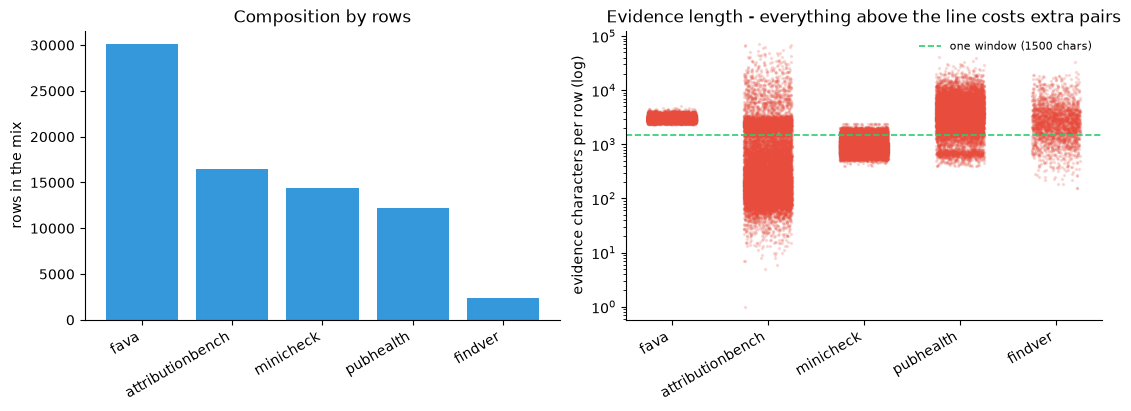

In [22]:
# Evidence length is what turns rows into pairs - the distribution behind the whole gate.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

groups = composition["group"].to_list()
ax = axes[0]
ax.bar(groups, composition["rows"].to_list(), color=COLOR_ROWS)
ax.set_ylabel("rows in the mix")
ax.set_title("Composition by rows")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

ax = axes[1]
for i, g in enumerate(groups):
    lengths = mix_df.filter(pl.col("group") == g)["chunk"].str.len_chars().to_numpy()
    ax.scatter(
        np.full(len(lengths), i) + np.random.uniform(-0.25, 0.25, len(lengths)),
        lengths,
        s=2,
        alpha=0.15,
        color=COLOR_PAIRS,
    )
ax.axhline(1500, color=COLOR_OK, linestyle="--", linewidth=1.2, label="one window (1500 chars)")
ax.set_yscale("log")
ax.set_xticks(range(len(groups)), groups)
ax.set_ylabel("evidence characters per row (log)")
ax.set_title("Evidence length - everything above the line costs extra pairs")
ax.legend(loc="upper right", frameon=False, fontsize=8)
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")

for a in axes:
    a.spines[["top", "right"]].set_visible(False)
plt.show()

## Conclusion

The pipeline ran end to end on CPU and produced a mix that is admissible by measurement rather than by
assumption.

- **Six corpora fetched from cache, six gated GREEN** - maximum overlap fraction 0.000231 against the
  walled arena, spike control detecting every injected unit, so the clean verdicts come from an
  instrument that demonstrably fires
- **Six lanes formatted to one schema** - three by manifest column mapping alone, three by adapter; every
  lane reproduced its declared row, positive and document counts
- **One corpus refused** - FActScore BLOCKs on document reuse (75.4 rows per document), pair-share
  capture (29.65% of the mix's pairs from 1.7% of its rows) and an over-cap tail of 1,341 rows
- **One corpus admitted with a documented drop** - AttributionBench loses 18 rows carrying 3,338 pairs,
  the largest a single row windowing into 533 pairs against a 96-pair batch
- **The mix is a GO** - no group blocks and no row exceeds the batch cap

The cost of finding this out here rather than in the trainer is the difference between a table and a
crashed run: the same defect previously surfaced as a batch-cap abort after the corpora had already been
licence-checked, contamination-gated, pair-formatted and declared banked supply.